# 🌌 Notebook 1 — Data Exploration & Preprocessing
**Dataset:** Stellar Classification (SDSS — Sloan Digital Sky Survey)

This notebook covers:
1. Library imports
2. Data loading & exploration
3. Feature selection (dropping non-informative ID columns)
4. Class distribution analysis & undersampling
5. Encoding & correlation analysis
6. Outlier removal (IQR method)
7. Scaling & train/test split


## 1. Library Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from warnings import filterwarnings
filterwarnings('ignore')


## 2. Load Data

In [2]:
df = pd.read_csv("star_classification.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Shape: (100000, 18)

Columns: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.describe()


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


## 3. Data Quality Check

The dataset contains values of `9999` which do not represent true measurements.
We also check for standard null values.


In [5]:
# Note: 9999 sentinel values exist — treat as missing if needed
# df.replace(9999, np.nan, inplace=True)

print("Null values per column:")
print(df.isna().sum())


Null values per column:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


## 4. Feature Selection

We drop identifier / administrative columns that carry no predictive information:
`obj_ID`, `run_ID`, `rerun_ID`, `field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`, `cam_col`


In [6]:
columns_to_drop = [
    'obj_ID', 'run_ID', 'rerun_ID', 'field_ID',
    'spec_obj_ID', 'plate', 'MJD', 'fiber_ID', 'cam_col'
]
df.drop(columns=columns_to_drop, axis=1, inplace=True)
df.dropna(inplace=True)

print("Shape after cleaning:", df.shape)
print("\nClass distribution:")
print(df['class'].value_counts())


Shape after cleaning: (100000, 9)

Class distribution:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


## 5. Class Distribution & Undersampling

The original dataset is imbalanced (~59% GALAXY, ~22% STAR, ~19% QSO).
To prevent the model from being biased towards the majority class,
we apply **random undersampling** to equalise all classes to the size of the minority class (QSO).


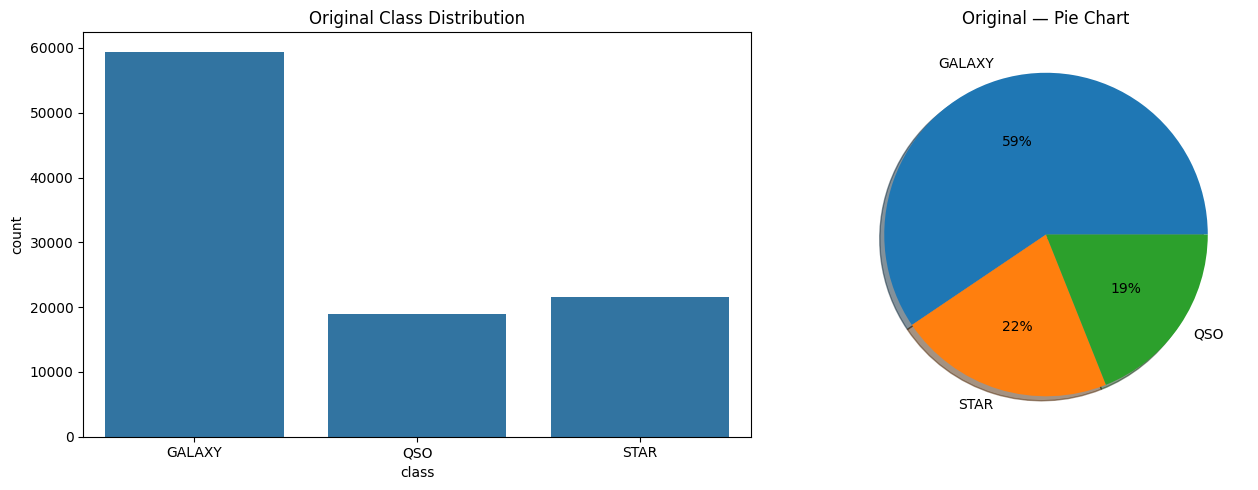

In [7]:
# Before undersampling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title("Original Class Distribution")
sns.countplot(data=df, x="class", ax=axes[0])

axes[1].set_title("Original — Pie Chart")
axes[1].pie(
    df['class'].value_counts(),
    labels=["GALAXY", "STAR", "QSO"],
    autopct="%1.f%%", shadow=True
)
plt.tight_layout()
plt.show()


In [8]:
galaxy = df[df['class'] == 'GALAXY']
star   = df[df['class'] == 'STAR']
qso    = df[df['class'] == 'QSO']
n_qso  = len(qso)

galaxy_resampled = resample(galaxy, replace=False, n_samples=n_qso, random_state=42)
star_resampled   = resample(star,   replace=False, n_samples=n_qso, random_state=42)

df_resampled = pd.concat([galaxy_resampled, star_resampled, qso])
df_resampled = df_resampled.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced class counts:")
print(df_resampled['class'].value_counts())


Balanced class counts:
class
QSO       18961
GALAXY    18961
STAR      18961
Name: count, dtype: int64


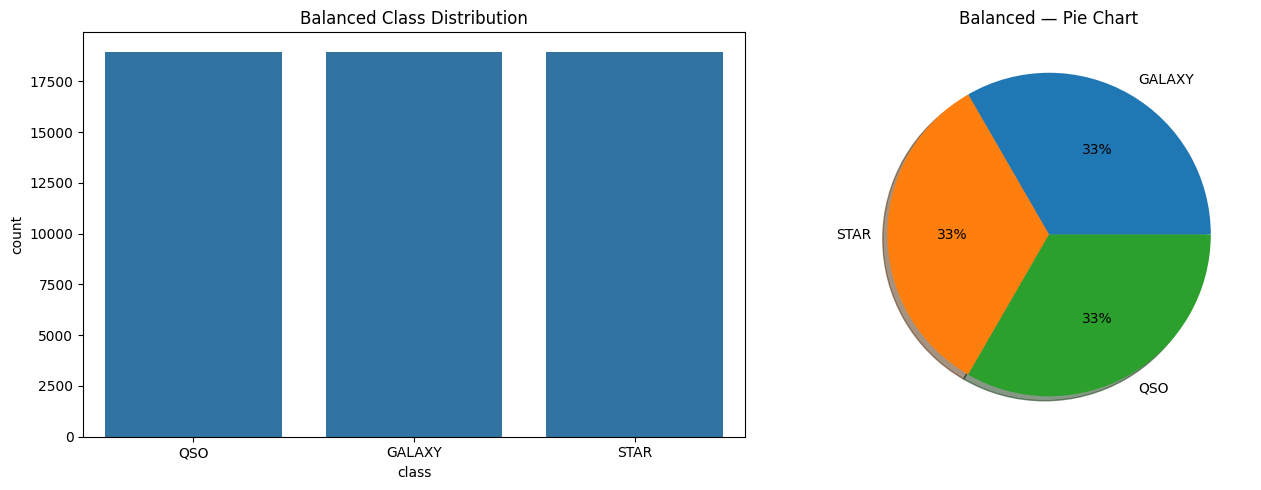

In [9]:
# After undersampling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title("Balanced Class Distribution")
sns.countplot(data=df_resampled, x="class", ax=axes[0])

axes[1].set_title("Balanced — Pie Chart")
axes[1].pie(
    df_resampled['class'].value_counts(),
    labels=["GALAXY", "STAR", "QSO"],
    autopct="%1.f%%", shadow=True
)
plt.tight_layout()
plt.show()


## 6. Label Encoding

In [10]:
encoder = LabelEncoder()
df_resampled['class'] = encoder.fit_transform(df_resampled['class'])

print("Class encoding:")
for i, name in enumerate(encoder.classes_):
    print(f"  {i} → {name}")


Class encoding:
  0 → GALAXY
  1 → QSO
  2 → STAR


## 7. Correlation Matrix

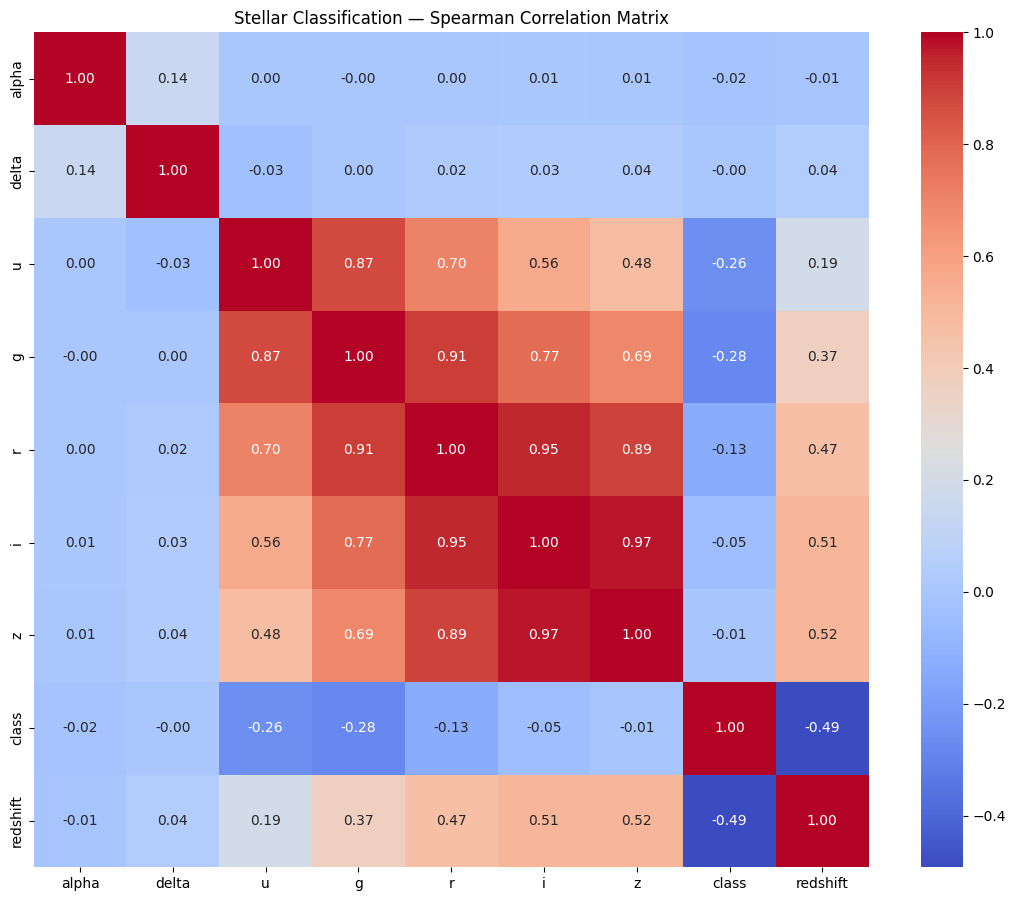

In [11]:
corr_mat = df_resampled.corr(method="spearman")

plt.figure(figsize=(11, 9))
sns.heatmap(corr_mat, annot=True, fmt="0.2f", cmap="coolwarm", square=True)
plt.title("Stellar Classification — Spearman Correlation Matrix")
plt.tight_layout()
plt.show()


## 8. KDE Feature Distribution

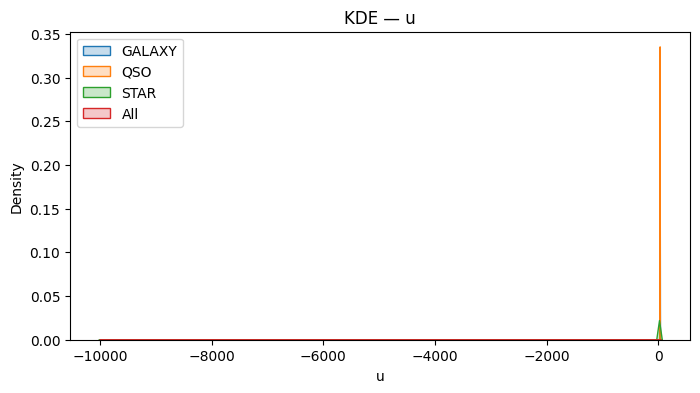

In [12]:
def plot_kde(column, df, encoder):
    plt.figure(figsize=(8, 4))
    for i in range(3):
        sns.kdeplot(
            data=df[df["class"] == i][column],
            label=encoder.inverse_transform([i])[0],
            fill=True
        )
    sns.kdeplot(data=df[column], label="All", fill=True)
    plt.title(f"KDE — {column}")
    plt.legend()
    plt.show()

# Example: photometric band 'u'
plot_kde('u', df_resampled, encoder)


## 9. Outlier Removal (IQR Method)

In [13]:
def remove_outliers_iqr(df, cols=None):
    """Remove rows where any value in `cols` lies outside 1.5 × IQR bounds."""
    df_clean = df.copy()
    original_n = len(df_clean)

    if cols is None:
        cols = df_clean.select_dtypes(include='number').columns

    for col in cols:
        q1, q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
        iqr = q3 - q1
        df_clean = df_clean[
            (df_clean[col] >= q1 - 1.5 * iqr) &
            (df_clean[col] <= q3 + 1.5 * iqr)
        ]

    print(f"Rows removed: {original_n - len(df_clean)}  |  Remaining: {len(df_clean)}")
    return df_clean

clean_star = remove_outliers_iqr(df_resampled)


Rows removed: 1962  |  Remaining: 54921


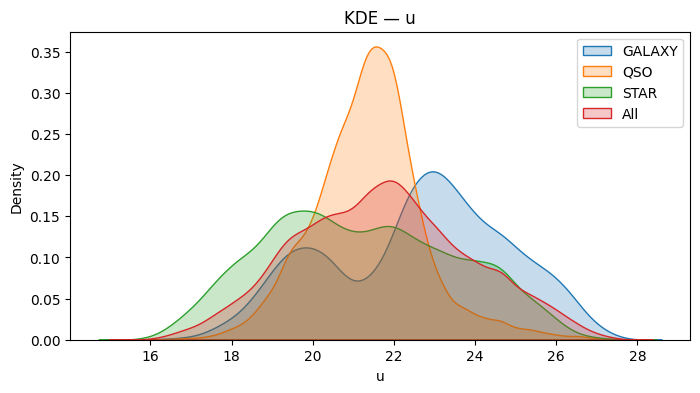

In [14]:
# KDE after outlier removal
plot_kde('u', clean_star, encoder)


## 10. Feature / Target Split & Scaling

In [15]:
X = clean_star.drop("class", axis=1)
y = clean_star['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)


Feature matrix shape: (54921, 8)


## 11. Train / Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print(f"Classes: {len(np.unique(y))}")


X_train: (38444, 8)  |  X_test: (16477, 8)
y_train: (38444,)  |  y_test: (16477,)
Classes: 3


## ✅ Save Splits & Encoder

In [17]:
import pickle, os
os.makedirs('data', exist_ok=True)

with open('data/splits.pkl', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)

with open('data/encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

with open('data/feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Saved: data/splits.pkl, data/encoder.pkl, data/feature_names.pkl")


Saved: data/splits.pkl, data/encoder.pkl, data/feature_names.pkl
